# Notebook Objectives

In this notebooks, we'll go through the main behavioral analysis results.

Results include:
* ?
* ?

---
# Setup


In [ ]:
from neural_value_function_helpers import *
from popy.config import COLORS



---
# Section 1: Get data, extract neural value

In [2]:
monkey, session, subregion = 'ka', '210322', 'MCC'

t_interest_fit = -4  # time point of interest for projection
t_interest_value = [-4.5, -3.5]

neural_dataset = load_data_custom(monkey, session, n_extra_trials=(0, 0))
neural_dataset = neural_dataset.sel(unit=neural_dataset.subregion==subregion)
neural_dataset

<xarray.Dataset>
Dimensions:           (unit: 16, trial_id: 417, time: 750)
Coordinates: (12/26)
  * unit              (unit) object 'MCC_06_01' 'MCC_07_01' ... 'MCC_16_01'
    unit_id_original  (unit) int64 26 28 66 33 32 30 35 ... 46 48 49 53 52 61 58
    channel           (unit) int64 6 7 7 8 8 8 9 10 11 12 12 13 13 14 16 16
    monkey            (unit) object 'ka' 'ka' 'ka' 'ka' ... 'ka' 'ka' 'ka' 'ka'
    session           (unit) object '210322' '210322' ... '210322' '210322'
    area              (unit) object 'MCC' 'MCC' 'MCC' ... 'MCC' 'MCC' 'MCC'
    ...                ...
    R_4               (trial_id) float64 0.0 1.0 0.0 0.0 0.0 ... 0.0 1.0 1.0 1.0
    R_5               (trial_id) float64 0.0 0.0 1.0 0.0 0.0 ... 1.0 0.0 1.0 1.0
    R_6               (trial_id) float64 1.0 0.0 0.0 1.0 0.0 ... 1.0 1.0 0.0 1.0
    R_7               (trial_id) float64 0.0 1.0 0.0 0.0 1.0 ... 0.0 1.0 1.0 0.0
    R_8               (trial_id) float64 0.0 0.0 1.0 0.0 0.0 ... 1.0 0.0 1.0 1.0
    fb_sequence       (trial_id) float64 1.0 0.0 4.0 6.0 7.0 ... 7.0 3.0 1.0 0.0
Data variables:
    firing_rates      (trial_id, unit, time) float64 -0.8091 -0.8091 ... -0.7246
Attributes:
    bin_size:  0.01

## Projection to value subspace

## Define the value subspace

In [3]:
floc = f'data/data_projected_temp_{monkey}_{subregion}_{str(t_interest_fit)}.nc'
target = 'R_1'

if True:#not os.path.exists(floc):
    #results, weights, data_projected, pvalue = time_resolved_decoder(neural_dataset, target='R_1', t_project=t_interest_fit)
    weights, data_projected = time_resolved_decoder_all_time(neural_dataset, target=target, t_project=t_interest_fit)

    # get neural value for the current trial and the previous one
    data_projected = add_neural_value_coord(data_projected, t_interest=t_interest_value)
    
    #print(f't= {t_interest_fit}, pvalue:', np.round(pvalue, 2))
    # save data_projected
    #data_projected.to_netcdf(floc)

    '''fig, axs = plot_decoder_results(data_projected.decodability, weights, n_extra_trials=(-1, 0))

    plt.suptitle(f'{monkey} {subregion} - decoding {target}')
    plt.tight_layout()'''
else:
    data_projected = xr.open_dataarray(floc)

data_projected

<xarray.DataArray (trial_id: 417, time: 750)>
array([[-0.16689456, -0.18345216, -0.21576098, ...,  0.42510888,
         0.36605214,  0.27205581],
       [-0.28629856, -0.31420457, -0.30779272, ...,  0.93463764,
         0.89746705,  0.76263094],
       [-0.56918777, -0.51394979, -0.44724154, ..., -0.08591924,
        -0.04793765, -0.03851724],
       ...,
       [ 0.88805614,  0.81720155,  0.73244234, ..., -0.11859514,
        -0.15168481, -0.20620749],
       [ 0.10387785,  0.07833895,  0.08588986, ...,  0.70981545,
         0.80668662,  0.93194045],
       [ 0.36450309,  0.47074974,  0.58508809, ...,  0.16173979,
         0.08694982,  0.03196135]])
Coordinates: (12/23)
  * trial_id      (trial_id) int64 8 9 10 11 12 13 ... 419 420 421 422 423 424
    block_id      (trial_id) int64 0 0 0 0 0 0 0 0 0 0 0 ... 9 9 9 9 9 9 9 9 9 9
    best_target   (trial_id) int64 1 1 1 1 1 1 1 1 1 1 1 ... 3 3 3 3 3 3 3 3 3 3
    target        (trial_id) float64 3.0 1.0 1.0 1.0 1.0 ... 3.0 3.0 3.0 3.0 2.0
    feedback      (trial_id) float64 0.0 1.0 1.0 1.0 1.0 ... 1.0 0.0 0.0 0.0 1.0
    stay_value    (trial_id) float64 0.1671 0.06983 0.4795 ... 0.3101 0.1831
    ...            ...
  * time          (time) float64 0.0 0.01 0.02 0.03 0.04 ... 7.46 7.47 7.48 7.49
    epoch         (time) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 5.0 5.0 5.0 5.0 5.0
    decodability  (time) float64 0.5132 0.5133 0.506 ... 0.4868 0.4963 0.4937
    V_t           (trial_id) float64 nan nan nan nan nan ... nan nan nan nan nan
    V_t_p1        (trial_id) float64 -0.03318 -0.2774 0.2867 ... -0.03664 -1.885
    dV            (trial_id) float64 nan nan nan nan nan ... nan nan nan nan nan

In [4]:
# normalize (mean substract)
#data_projected = data_projected - data_projected.mean(dim='trial_id')

Text(0.5, 0.98, 'ka MCC, t_fit = -4s, t_eval = [-4.5, -3.5]s')

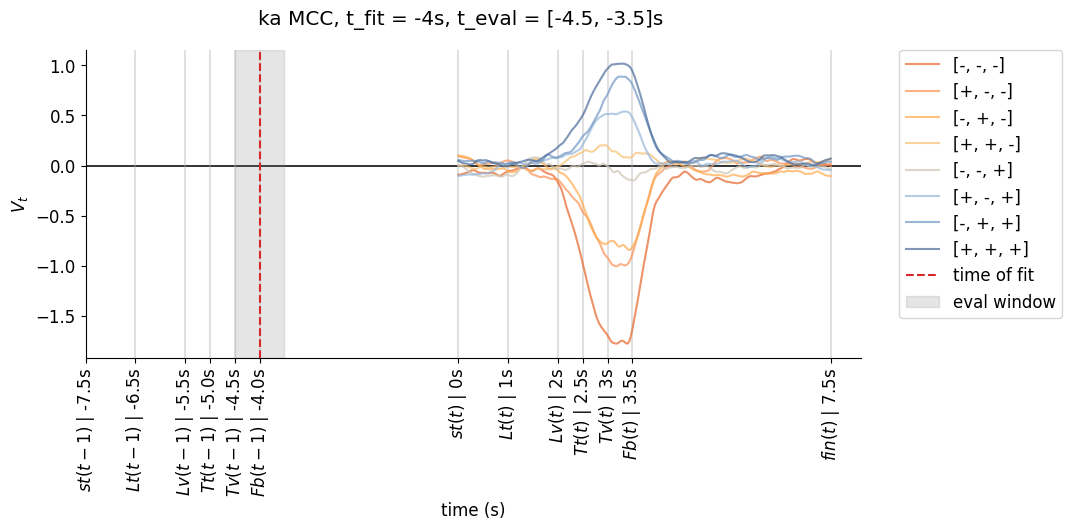

In [5]:
fig, ax = plot_projected_data(data_projected, t_interest_fit, t_interest_value, n_extra_trials=(-1, 0), xlim=None, paper_format=False)

plt.suptitle(f'{monkey} {subregion}, t_fit = {t_interest_fit}s, t_eval = {t_interest_value}s')


## Extract neural value

In [6]:
behav_new = data_projected.mean('time').coords.to_dataset().to_dataframe().reset_index()

behav_new['monkey'] = monkey
behav_new['session'] = session
#behav_new['area'] = neural_dataset.area
behav_new['subregion'] = subregion
behav_new


,trial_id,block_id,best_target,target,feedback,stay_value,V0,stay_proba,R_1,R_2,...,R_6,R_7,R_8,fb_sequence,V_t,V_t_p1,dV,monkey,session,subregion
0,8,0,1,3.0,0.0,0.167107,0.118275,0.627026,0.0,0.0,...,1.0,0.0,0.0,1.0,NaN,-0.033182,NaN,ka,210322,MCC
1,9,0,1,1.0,1.0,0.069825,0.118275,0.373927,0.0,0.0,...,0.0,1.0,0.0,0.0,NaN,-0.277363,NaN,ka,210322,MCC
2,10,0,1,1.0,1.0,0.479459,0.118275,0.979006,1.0,0.0,...,0.0,0.0,1.0,4.0,NaN,0.286666,NaN,ka,210322,MCC
3,11,0,1,1.0,1.0,0.692690,0.118275,0.997786,1.0,1.0,...,1.0,0.0,0.0,6.0,NaN,0.704768,NaN,ka,210322,MCC
4,12,0,1,1.0,1.0,0.818575,0.118275,0.999419,1.0,1.0,...,0.0,1.0,0.0,7.0,NaN,1.076227,NaN,ka,210322,MCC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412,420,9,3,3.0,1.0,0.813273,0.118275,0.999385,1.0,1.0,...,0.0,1.0,0.0,6.0,NaN,-0.176794,NaN,ka,210322,MCC
413,421,9,3,3.0,0.0,0.889763,0.118275,0.999727,1.0,1.0,...,1.0,0.0,1.0,7.0,NaN,0.245973,NaN,ka,210322,MCC
414,422,9,3,3.0,0.0,0.525286,0.118275,0.987001,0.0,1.0,...,1.0,1.0,0.0,3.0,NaN,-0.125566,NaN,ka,210322,MCC
415,423,9,3,3.0,0.0,0.310111,0.118275,0.885011,0.0,0.0,...,0.0,1.0,1.0,1.0,NaN,-0.036639,NaN,ka,210322,MCC


---
# Section 2: Analysis of the neural value representation

In [7]:
'''behav_new = pd.read_pickle('/Users/zsombi/Library/CloudStorage/GoogleDrive-uuungvarszi@gmail.com/Other computers/My Mac/ZSOMBI/SBRI/PoPy/notebooks/population_decoding/results/behav_neural_value_copy/behav.pkl')
#behav_new = behav_new.loc[behav_new.subregion=='dLPFC']
behav_new'''

"behav_new = pd.read_pickle('/Users/zsombi/Library/CloudStorage/GoogleDrive-uuungvarszi@gmail.com/Other computers/My Mac/ZSOMBI/SBRI/PoPy/notebooks/population_decoding/results/behav_neural_value_copy/behav.pkl')\n#behav_new = behav_new.loc[behav_new.subregion=='dLPFC']\nbehav_new"

## Green red plot: Value evolves according to feedback

     trial_id  V_t  dV  feedback fb_sequence fb_sequence_last_2
0           8  NaN NaN       0.0     0\n0\n1               0\n1
1           9  NaN NaN       1.0     0\n0\n0               0\n0
2          10  NaN NaN       1.0     1\n0\n0               0\n0
3          11  NaN NaN       1.0     1\n1\n0               1\n0
4          12  NaN NaN       1.0     1\n1\n1               1\n1
..        ...  ...  ..       ...         ...                ...
412       420  NaN NaN       1.0     1\n1\n0               1\n0
413       421  NaN NaN       0.0     1\n1\n1               1\n1
414       422  NaN NaN       0.0     0\n1\n1               1\n1
415       423  NaN NaN       0.0     0\n0\n1               0\n1
416       424  NaN NaN       1.0     0\n0\n0               0\n0

[417 rows x 6 columns]


/Users/zsombi/Library/CloudStorage/GoogleDrive-uuungvarszi@gmail.com/Other computers/My Mac/ZSOMBI/SBRI/PoPy/notebooks/population_decoding/neural_value_function_helpers.py:434: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df.sort_values('fb_sequence'), x='fb_sequence', y='V_t', palette=colors, ax=ax, showfliers=False, boxprops={'linewidth': 0.5})


UnboundLocalError: local variable 'boxprops' referenced before assignment

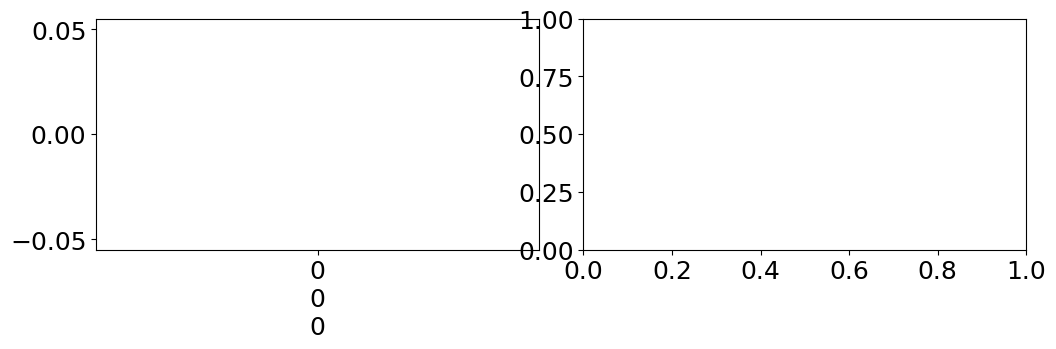

In [8]:
fig, ax = projection_timepoint(behav_new, paper_format=False, ylim=None, show_datapoints=False)
plt.suptitle(f'{monkey} {subregion}, t_fit = {t_interest_value} s')


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


# Data setup
weights_all = []
for monkey in behav_new.monkey.unique():
    for subregion in behav_new.subregion.unique():
        behav_temp = behav_new.loc[(behav_new.monkey == monkey) & (behav_new.subregion == subregion)]

        for session in behav_temp.session.unique():
            behav = behav_temp.loc[behav_temp.session == session].copy()

            y = behav.V_t.values
            X = np.array([behav[f'R_{i}'].values for i in range(1, 9)]).T

            # Add intercept for statsmodels
            X_sm = sm.add_constant(X)
            model = sm.OLS(y, X_sm)
            results = model.fit()

            # Extract weights and p-values (skip intercept)
            weights = results.params[1:]
            pvals = results.pvalues[1:]
            
            res_temp = {f'R_{i}': results.params[i] for i in range(1, len(weights) + 1)}
            res_temp['monkey'] = monkey
            res_temp['session'] = session
            res_temp['subregion'] = subregion
            weights_all.append(res_temp)

weights_all = pd.DataFrame(weights_all)
weights_all

,R_1,R_2,R_3,R_4,R_5,R_6,R_7,R_8,monkey,session,subregion
0,2.075183,0.166996,0.120581,0.009141,0.057291,0.229832,0.027507,0.176868,ka,210322,MCC


/Users/zsombi/anaconda3/envs/popy_local/lib/python3.10/site-packages/statsmodels/stats/weightstats.py:994: RuntimeWarning: invalid value encountered in scalar divide
  (d1.sumsquares + d2.sumsquares)


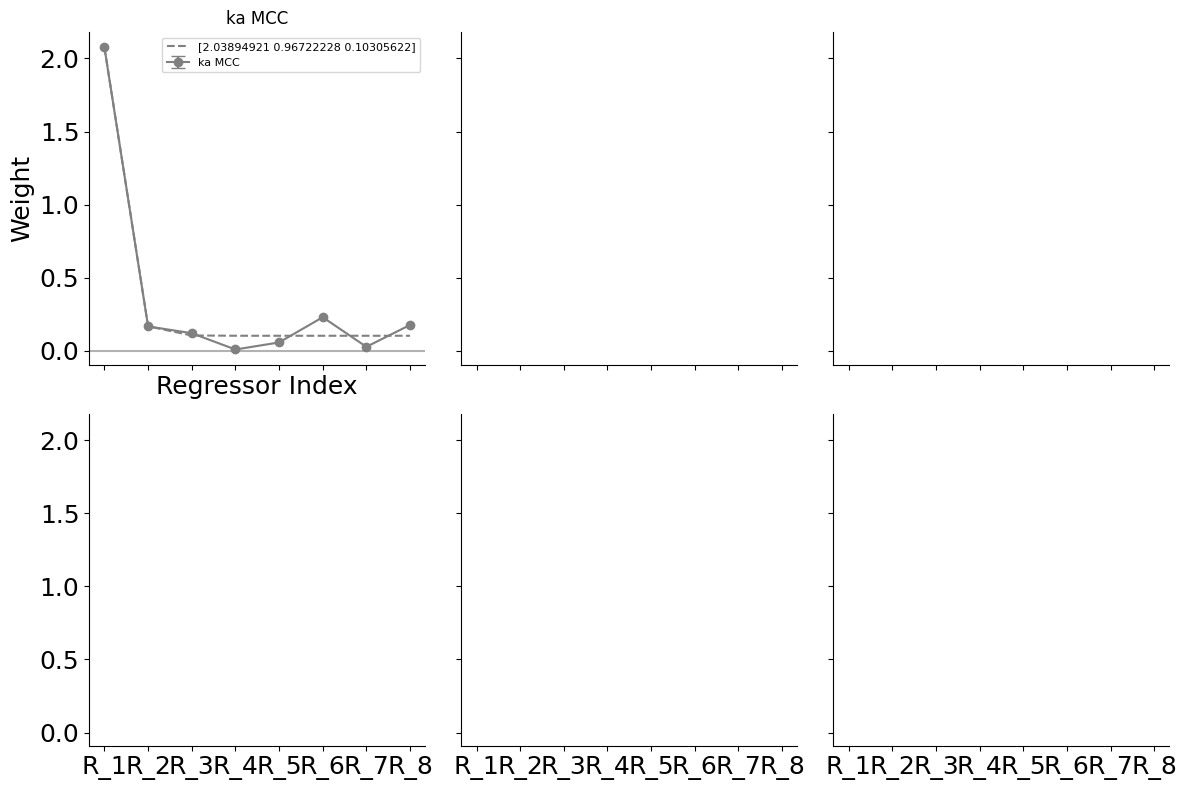

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
# font size
plt.rcParams.update({'font.size': 10})

for m, monkey in enumerate(behav_new.monkey.unique()):
    for s, subregion in enumerate(behav_new.subregion.unique()):
        ax = axs[m, s]

        weights_temp = weights_all.loc[(weights_all.monkey == monkey) & (weights_all.subregion == subregion)]
        weights_temp = weights_temp.drop(columns=['monkey', 'session', 'subregion'])

        # Visualization - mean weights with error bars and in the background plot individual sessions with lines connecting them
        # weights temp is a DataFrame with weights for each regressor
        weights = weights_temp.mean().values
        weights_err = weights_temp.std().values / np.sqrt(len(weights_temp))
        ax.errorbar(range(1, len(weights) + 1), weights, yerr=weights_err, fmt='o', 
                    label=f'{monkey} {subregion}', color=COLORS[subregion], linestyle='-',
                    alpha=1, capsize=5, zorder=2)
        
        # fit exponential and print params
        def exponential_fit(x, C, a, b):
            return C*(a * (1-a) ** (x - 1)) + b
        from scipy.optimize import curve_fit
        x_data = np.arange(1, len(weights) + 1)
        popt, _ = curve_fit(exponential_fit, x_data, weights, p0=(1, 0.5, 0))
        fit_line = exponential_fit(x_data, *popt)
        ax.plot(x_data, fit_line, color=COLORS[subregion], linestyle='--', label=f'{popt}', zorder=1)


        # Plot individual session weights
        for i, row in weights_temp.iterrows():
            ax.plot(range(1, len(weights) + 1), row.values, color='grey', alpha=0.1)

        # see if the weights are significantly different from reference (R_8)
        reference_weight = weights_temp['R_8'].values
        for i in range(1, len(weights) + 1):
            if i == 8:
                continue
            _, pval, _ = sm.stats.ttest_ind(weights_temp[f'R_{i}'].values, reference_weight, alternative='two-sided')
            if pval < 0.05 and pval >= 0.01:
                ax.text(i, weights[i-1] + 0.02, '*', color='red', fontsize=12, ha='center')
            elif pval < 0.01:
                ax.text(i, weights[i-1] + 0.02, '**', color='red', fontsize=12, ha='center')
            elif pval < 0.001:
                ax.text(i, weights[i-1] + 0.02, '***', color='red', fontsize=12, ha='center')
            
        # Plot the weights as a bar plot

        
        #ax.scatter(range(1, len(weights) + 1), weights, color='steelblue', alpha=0.7, s=80, edgecolor='k')
        ax.axhline(0, color='black', linestyle='-', alpha=0.3)
        ax.set_xlabel('Regressor Index')
        ax.set_ylabel('Weight')
        ax.set_xticks(range(1, len(weights) + 1))
        ax.set_xticklabels([f'R_{i}' for i in range(1, len(weights) + 1)])
        #ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right', fontsize=8)
        sns.despine()

        #ax.set_ylim(-0.05, 0.5)

        ax.set_title(f'{monkey} {subregion}')

plt.tight_layout()


In [ ]:
'''value_behav = data_projected.stay_value.data
value_neural = data_projected.V_t.data
dV_neural = data_projected.dV.data
feedback = np.array([int(x) for x in data_projected.feedback.data])

x, y = value_behav[feedback==1], dV_neural[feedback==1]
from scipy import stats
m, b, r_value, p_value, std_err = stats.linregress(x, y)

plt.plot(x, m*x+b, 'tab:green', linewidth=5, label=f'R: {r_value:.1f}, p: {p_value:.3f}')
plt.scatter(x, y, color='tab:green', alpha=.5)

x, y = value_behav[feedback==0], dV_neural[feedback==0]
from scipy import stats
m, b, r_value, p_value, std_err = stats.linregress(x, y)

plt.plot(x, m*x+b, 'tab:red', linewidth=5, label=f'R: {r_value:.1f}, p: {p_value:.3f}')
plt.scatter(x, y, color='tab:red', alpha=.5)

plt.axhline(0, linestyle='--', color='black')
#plt.scatter(value_behav, value_neural, color='grey', s=10)
plt.legend()
plt.xlabel('V_t (behav)')
plt.ylabel('dV neural')'''

"value_behav = data_projected.stay_value.data\nvalue_neural = data_projected.V_t.data\ndV_neural = data_projected.dV.data\nfeedback = np.array([int(x) for x in data_projected.feedback.data])\n\nx, y = value_behav[feedback==1], dV_neural[feedback==1]\nfrom scipy import stats\nm, b, r_value, p_value, std_err = stats.linregress(x, y)\n\nplt.plot(x, m*x+b, 'tab:green', linewidth=5, label=f'R: {r_value:.1f}, p: {p_value:.3f}')\nplt.scatter(x, y, color='tab:green', alpha=.5)\n\nx, y = value_behav[feedback==0], dV_neural[feedback==0]\nfrom scipy import stats\nm, b, r_value, p_value, std_err = stats.linregress(x, y)\n\nplt.plot(x, m*x+b, 'tab:red', linewidth=5, label=f'R: {r_value:.1f}, p: {p_value:.3f}')\nplt.scatter(x, y, color='tab:red', alpha=.5)\n\nplt.axhline(0, linestyle='--', color='black')\n#plt.scatter(value_behav, value_neural, color='grey', s=10)\nplt.legend()\nplt.xlabel('V_t (behav)')\nplt.ylabel('dV neural')"

t-statistic: 0.09881264801258065, p-value: 0.921334736272094


Text(0.5, 0.98, 'ka MCC, t_fit = [-3.5, -2.5] s')

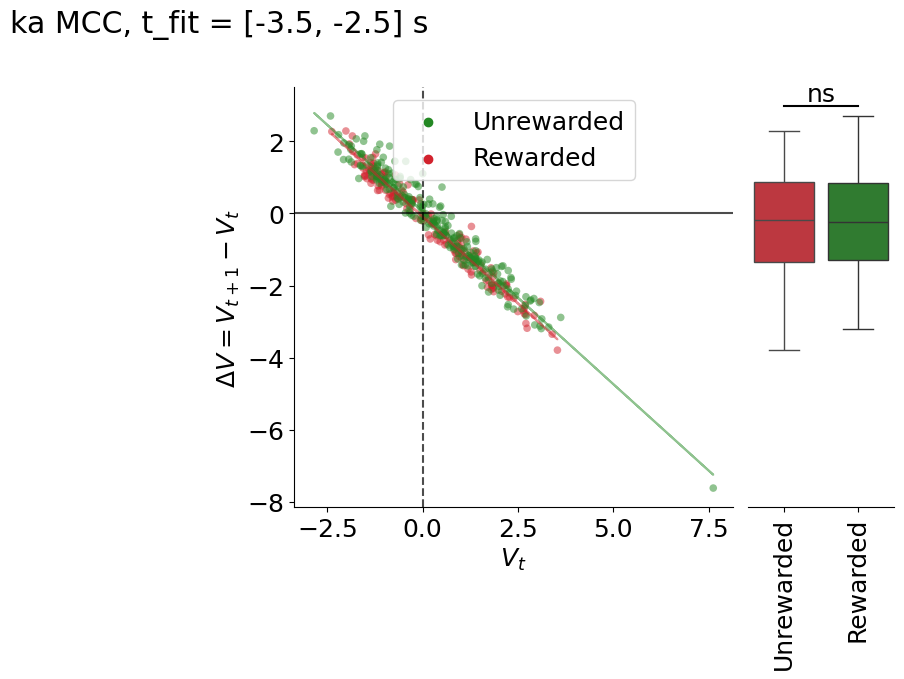

In [ ]:
fig, ax = green_red_plot(behav_new, paper_format=False, xlim=None, ylim=None)
plt.suptitle(f'{monkey} {subregion}, t_fit = {t_interest_value} s')

#fig.savefig(f'figs/green_red_plot_{monkey}_{subregion}.svg', bbox_inches='tight', transparent=True, dpi=300)